In [1]:
import os
import base64
import json
import random
from openai import OpenAI
import anthropic
import numpy as np
import re
from tqdm import tqdm
import pandas as pd
import time
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import copy
import traceback
from transformers import Blip2Processor, Blip2ForConditionalGeneration
from PIL import Image
import torch
import io

/Users/wt/PythonProjects/Multi_Agent_Cartoon/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load Dataset

In [43]:
# Set base directory using relative path
base_dir = os.path.join(os.getcwd(), "dataset", "pororo")
qa_json_path = os.path.join(base_dir, "qa.json")
description_csv_path = os.path.join(base_dir, "descriptions.csv")

def load_dataset(qa_json_path, description_csv_path):
    try:
        with open(qa_json_path, "r") as f:
            qa_data = json.load(f)["PororoQA"]
        descriptions = pd.read_csv(description_csv_path)
        return qa_data, descriptions
    except Exception as e:
        print(f"Error loading dataset: {e}")
        return [], pd.DataFrame()

def load_subtitles(video_name):
    """Load subtitles for a specific episode and return them as a string"""
    episode_parts = video_name.split("_")
    episode_folder = os.path.join(base_dir, "Scenes_Dialogues",
                                "_".join(episode_parts[:-1]),
                                video_name)
    subtitle_path = os.path.join(episode_folder, "subtitles.txt")

    try:
        if os.path.exists(subtitle_path):
            with open(subtitle_path, "r") as f:
                return f.read()
        else:
            print(f"Warning: Subtitle file not found at {subtitle_path}")
            return ""
    except Exception as e:
        print(f"Error loading subtitles for {video_name}: {e}")
        return ""

def subtitles_to_gifs(video_name, gif_nums, descriptions_df=None):
    """
    Create a mapping between GIF numbers and subtitles
    This function maps subtitles with their corresponding GIFs by gif number
    Each GIF number should have a corresponding subtitle line
    """
    # Load full subtitles for the episode
    full_subtitles = load_subtitles(video_name)

    # Create mapping dictionary
    subtitle_mapping = {}

    # Process the subtitles based on line breaks
    subtitle_lines = [line for line in full_subtitles.split("\n") if line.strip()]

    # Sort GIF numbers to ensure proper order
    sorted_gif_nums = sorted([int(num) for num in gif_nums])

    # Create mapping between GIFs and subtitle lines
    # Assuming GIF numbers correspond to subtitle line numbers (1-indexed)
    for gif_num in sorted_gif_nums:
        # Convert to string for dictionary key
        gif_num_str = str(gif_num)

        # GIF numbers are 1-indexed, but list indices are 0-indexed
        line_index = gif_num - 1

        if 0 <= line_index < len(subtitle_lines):
            subtitle_mapping[gif_num_str] = subtitle_lines[line_index]
        else:
            subtitle_mapping[gif_num_str] = ""  # No subtitle available for this GIF

    return subtitle_mapping

# Global variable for caching dataset
cached_dataset = None

# Function to get a fresh copy of the dataset
def get_fresh_dataset(reload=False):
    global cached_dataset

    # If no cache or forced reload, read from disk
    if cached_dataset is None or reload:
        qa_data, descriptions = load_dataset(qa_json_path, description_csv_path)
        cached_dataset = {
            'qa_data': qa_data,
            'descriptions': descriptions,
            'gif_paths': {},
            'question_data': {},
            'subtitle_mappings': {}
        }
    else:
        print("Using cached dataset but creating deep copy to prevent contamination...")

    # Always return deep copy to prevent cross-configuration contamination
    return copy.deepcopy(cached_dataset['qa_data']), \
           cached_dataset['descriptions'].copy(deep=True)

# TODO increase questions
def get_random_questions(qa_data, max_questions=40, base_pattern="Pororo_ENGLISH1", seed=42):
    random.seed(seed)

    # Filter all eligible questions
    filtered_questions = [q for q in qa_data if base_pattern in q["video_name"]]

    # Group by unique (video_name, supporting_num) pairs to avoid duplicates
    unique_pairs = {}
    for q in filtered_questions:
        key = (q["video_name"], q["supporting_num"])
        if key not in unique_pairs:
            unique_pairs[key] = []
        unique_pairs[key].append(q)

    # Sample from unique pairs
    unique_keys = list(unique_pairs.keys())
    selected_keys = random.sample(unique_keys, min(max_questions, len(unique_keys)))

    # Get one question from each selected pair
    sampled_questions = []
    episode_counts = {}

    for key in selected_keys:
        question = random.choice(unique_pairs[key])
        sampled_questions.append(question)
        episode = question["video_name"]
        episode_counts[episode] = episode_counts.get(episode, 0) + 1

    # Group by season for display
    season_episodes = {
        "Pororo_ENGLISH1_1": [],
        "Pororo_ENGLISH1_2": [],
        "Pororo_ENGLISH1_3": []
    }

    for ep in episode_counts.keys():
        season = "_".join(ep.split("_")[:3])
        if season in season_episodes:
            season_episodes[season].append(ep)

    # Do not print here; return the info for printing elsewhere
    return sampled_questions, episode_counts, season_episodes

def get_seeded_question(questions, gif_num, base_seed=42):
    """Get deterministic random question for a GIF"""
    if not questions:
        return None
    local_random = random.Random(base_seed + gif_num)
    sorted_questions = sorted(questions, key=lambda x: x["qid"])
    return local_random.choice(sorted_questions)

def encode_gif(gif_path):
    try:
        if not os.path.exists(gif_path):
            print(f"Error: GIF not found at {gif_path}")
            return None
        with open(gif_path, "rb") as gif_file:
            image_base64 = base64.b64encode(gif_file.read()).decode('utf-8')
            return image_base64
    except Exception as e:
        print(f"Error encoding GIF: {e}")
        return None

def prepare_dataset():
    """Prepare a new dataset with isolated question data and gif paths"""
    # Get a fresh copy of the dataset
    qa_data, descriptions = get_fresh_dataset()

    # Get a random sample of questions and episode information
    sampled_questions, episode_counts, season_episodes = get_random_questions(qa_data, max_questions=40)

    # Group questions by supporting_num
    grouped_questions = {}
    for entry in sampled_questions:
        video_name = entry["video_name"]
        supporting_num = entry["supporting_num"]
        key = (video_name, supporting_num)
        if key not in grouped_questions:
            grouped_questions[key] = []
        grouped_questions[key].append(entry)

    # Get unique key-value pairs to process
    gif_pairs = sorted(list(grouped_questions.keys()))

    # Prepare question data and gif paths
    question_data = {}
    gif_paths = {}

    for video_name, gif_num in gif_pairs:
        current_questions = grouped_questions[(video_name, gif_num)]
        if current_questions:
            entry = get_seeded_question(current_questions, int(gif_num))

            question = entry["question"]
            correct_idx = entry["correct_idx"]
            answers = [entry[f"answer{i}"] for i in range(5)]
            correct_answer = answers[correct_idx]
            qid = entry["qid"]

            question_data[(video_name, gif_num)] = {
                'entry': entry,
                'question': question,
                'correct_answer': correct_answer,
                'qid': qid
            }

            # gif path
            episode_parts = video_name.split("_")
            episode_folder = os.path.join(base_dir, "Scenes_Dialogues",
                                "_".join(episode_parts[:-1]),
                                video_name)
            gif_paths[(video_name, gif_num)] = os.path.join(episode_folder, f"{gif_num}.gif")

    return descriptions, gif_pairs, question_data, gif_paths

def print_dataset_summary(sampled_questions, episode_counts, season_episodes):
    print(f"\nSelected {len(sampled_questions)} questions from {len(episode_counts)} episodes:")

    for season in sorted(season_episodes.keys()):
        season_eps = {ep: episode_counts[ep] for ep in season_episodes[season]}
        if season_eps:
            print(f"\n{season}:")
            for ep in sorted(season_eps.keys()):
                print(f"  {ep}: {season_eps[ep]} questions")

# Example of loading and displaying dataset information
qa_data, descriptions = get_fresh_dataset()
sampled_questions, episode_counts, season_episodes = get_random_questions(qa_data, max_questions=40)
print_dataset_summary(sampled_questions, episode_counts, season_episodes)

# Initialize results list
results_ablation = []

# Ablation Study Configuration
# Initializing the agents
ENABLE_VISUAL_AGENT = False
ENABLE_LANGUAGE_AGENT = False
ENABLE_CRITIC_AGENT = False


Selected 40 questions from 22 episodes:

Pororo_ENGLISH1_1:
  Pororo_ENGLISH1_1_ep1: 1 questions
  Pororo_ENGLISH1_1_ep10: 2 questions
  Pororo_ENGLISH1_1_ep11: 1 questions
  Pororo_ENGLISH1_1_ep12: 4 questions
  Pororo_ENGLISH1_1_ep13: 2 questions
  Pororo_ENGLISH1_1_ep2: 4 questions
  Pororo_ENGLISH1_1_ep5: 1 questions
  Pororo_ENGLISH1_1_ep6: 4 questions
  Pororo_ENGLISH1_1_ep9: 1 questions

Pororo_ENGLISH1_2:
  Pororo_ENGLISH1_2_ep10: 1 questions
  Pororo_ENGLISH1_2_ep2: 2 questions
  Pororo_ENGLISH1_2_ep5: 2 questions
  Pororo_ENGLISH1_2_ep8: 3 questions

Pororo_ENGLISH1_3:
  Pororo_ENGLISH1_3_ep1: 1 questions
  Pororo_ENGLISH1_3_ep11: 1 questions
  Pororo_ENGLISH1_3_ep12: 2 questions
  Pororo_ENGLISH1_3_ep13: 1 questions
  Pororo_ENGLISH1_3_ep2: 1 questions
  Pororo_ENGLISH1_3_ep3: 1 questions
  Pororo_ENGLISH1_3_ep4: 1 questions
  Pororo_ENGLISH1_3_ep5: 2 questions
  Pororo_ENGLISH1_3_ep7: 2 questions


# Agent Configuration

In [ ]:
load_dotenv()
# Configuration
# MODEL_NAME = "claude-3-5-haiku-20241022"
MODEL_NAME = "gpt-4o-mini"

is_openai_model = not MODEL_NAME.startswith("claude-")

if is_openai_model:
    client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
    print(f"Using OpenAI model: {MODEL_NAME}")
else:
    client = anthropic.Anthropic(api_key=os.getenv("ANTHROPIC_API_KEY"))
    print(f"Using Anthropic model: {MODEL_NAME}")

# Agent Implementations

# BLIP2 Visual Question Answering Class
class Blip2QA:
    def __init__(self, model_name="Salesforce/blip2-flan-t5-xl", dtype=torch.float16):
        # For macOS system: Detect and configure MPS device
        if torch.backends.mps.is_available():
            self.device = torch.device("mps")
            print("Using MPS (Metal Performance Shaders) acceleration")
        else:
            self.device = torch.device("cpu")
            print("Using CPU")
        
        # Optimized processor loading (eliminate use_fast warning)
        self.processor = Blip2Processor.from_pretrained(
            model_name,
            use_fast=True  # Explicitly specify using fast processor
        )
        
        self.model = Blip2ForConditionalGeneration.from_pretrained(
            model_name,
            dtype=dtype,  # Use dtype instead of torch_dtype
            low_cpu_mem_usage=True,
            device_map={"": self.device}
        )

    def ask_question(self, image_path, question, max_new_tokens=50):
        image = Image.open(image_path).convert("RGB")
        prompt = f"Question: {question}"
    
        # Optimize device allocation
        inputs = self.processor(images=image, text=prompt, return_tensors="pt")
        inputs = {k: v.to(self.device) for k, v in inputs.items()}
        
        with torch.no_grad():
            generated_ids = self.model.generate(**inputs, max_new_tokens=max_new_tokens)
            answer = self.processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()
        
        return answer

    def ask_question_from_base64(self, image_base64, question, max_new_tokens=50):
        """Process image from base64 string"""
        # Decode base64 to PIL image
        image_data = base64.b64decode(image_base64)
        image = Image.open(io.BytesIO(image_data)).convert("RGB")
        
        prompt = f"Question: {question}"
        
        # Optimize device allocation
        inputs = self.processor(images=image, text=prompt, return_tensors="pt")
        inputs = {k: v.to(self.device) for k, v in inputs.items()}
        
        with torch.no_grad():
            generated_ids = self.model.generate(**inputs, max_new_tokens=max_new_tokens)
            answer = self.processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()
        
        return answer

# Initialize BLIP2 model globally
blip2_qa = None

def initialize_blip2():
    global blip2_qa
    if blip2_qa is None:
        print("Initializing BLIP2 model...")
        blip2_qa = Blip2QA()
        print("BLIP2 model initialized successfully!")

# Visual agent: handles image-related tasks using BLIP2, and outputs image description
def visual_agent(image_base64, question, description, subtitles, max_retries=5, retry_delay=10):
    # If visual agent is disabled, return placeholder
    if not ENABLE_VISUAL_AGENT:
        return "This is a cartoon image from Pororo."
    
    # For true ablation study:
    # 1. visual_language should generate visual descriptions
    # 2. visual_language_critic should use cached visual descriptions

    # Only generate visual descriptions in the visual_language configuration
    # In visual_language_critic, it should use cached results
    if ENABLE_CRITIC_AGENT and ENABLE_VISUAL_AGENT:
        print("Error: Attempting to call visual_agent in visual_language_critic - should use cached")
        return "This is a cartoon image from Pororo."

    # Initialize BLIP2 if needed
    initialize_blip2()
    
    try:
        # Use BLIP2 to directly answer questions, increase max_new_tokens for more complete answers
        answer = blip2_qa.ask_question_from_base64(image_base64, question, max_new_tokens=80)
        
        def clean_repeated_words(text):
            """
            Clean repeated words and characters in text, keeping the first occurrence of each consecutive repeated word sequence
            Example: "a crocodal crocodal crocodal" -> "a crocodal"
                     "eeeeeeee" -> "e"
            """
            if not text or not isinstance(text, str):
                return text
            
            # First check if it's single character repetition (like "eeeeeee")
            # If so, directly return that character
            if len(text) > 5:
                unique_chars = set(text.replace(' ', ''))
                if len(unique_chars) == 1 and len(text) > 3:
                    # All the same character, return single occurrence of that character
                    return list(unique_chars)[0]
            
            words = text.split()
            if len(words) <= 1:
                return text
            
            # Remove consecutive repeated words
            cleaned_words = [words[0]]
            for i in range(1, len(words)):
                # Only add if current word is different from previous word
                if words[i].lower() != words[i-1].lower():
                    cleaned_words.append(words[i])
            
            cleaned_text = ' '.join(cleaned_words)
            
            # Additional processing: detect repeated phrase patterns (like "a frog and a frog and")
            # If obvious phrase repetition is detected, further clean it
            words_after_first_clean = cleaned_text.split()
            if len(words_after_first_clean) >= 6:
                # Try to detect 2-4 word repeated phrase patterns
                for pattern_len in range(2, min(5, len(words_after_first_clean) // 2 + 1)):
                    pattern = ' '.join(words_after_first_clean[:pattern_len])
                    # Count how many times this pattern appears in the text
                    pattern_count = cleaned_text.count(pattern)
                    
                    # If phrase repeats 3 or more times, keep only first occurrence
                    if pattern_count >= 3:
                        # Find the position of first occurrence
                        first_occurrence_end = cleaned_text.index(pattern) + len(pattern)
                        # Keep only up to the first occurrence
                        cleaned_text = cleaned_text[:first_occurrence_end].strip()
                        break
            
            return cleaned_text
        
        def is_valid_answer(text):
            """
            Check if BLIP2 answer is valid
            Note: This function only detects truly invalid output, not repetitions (repetitions are handled by clean_repeated_words)
            """
            if not text or not isinstance(text, str) or len(text.strip()) == 0:
                return False
            
            text = text.strip().lower()
            
            # Strategy 1: Detect extremely short output
            if len(text) < 3:
                return False
            
            # Strategy 2: Detect completely composed of single character (like "eeeeee")
            unique_chars = set(text.replace(' ', ''))
            if len(unique_chars) == 1:
                return False
            
            # Strategy 3: For longer text, use character ratio detection
            # If a character accounts for more than 70% of all letters, consider it a repeated character error
            if len(text) > 5:
                char_counts = {}
                for char in text:
                    if char.isalpha():  # Only count letters
                        char_counts[char] = char_counts.get(char, 0) + 1
                
                if char_counts:
                    max_count = max(char_counts.values())
                    total_alpha = sum(char_counts.values())
                    
                    # Character ratio exceeding 70% is considered invalid
                    if total_alpha > 0 and (max_count / total_alpha) > 0.7:
                        return False
            
            return True
        
        # Step 1: Clean repeated words
        cleaned_answer = clean_repeated_words(answer)
        
        # Step 2: Verify if cleaned answer is valid
        if not is_valid_answer(cleaned_answer):
            print(f"Warning: Invalid BLIP2 answer after cleaning: '{answer[:80]}...' -> '{cleaned_answer[:80]}...'")
            return None  # Return None indicates generation failure, let caller decide how to handle
        
        # If cleaned answer differs from original answer, it means repetitions were removed
        if cleaned_answer != answer:
            print(f"Cleaned repeated words: '{answer[:80]}...' -> '{cleaned_answer}'")
        
        # Return cleaned answer
        return cleaned_answer
        
    except Exception as e:
        print(f"Error using BLIP2: {e}")
        traceback.print_exc()
        
        # If BLIP2 fails, return None
        return None

def visual_json_to_text(visual_json, question):
    # Simplified function - visual_json is now directly a string
    if isinstance(visual_json, str):
        # Directly return string
        if visual_json and visual_json not in ["This is a cartoon image from Pororo.", 
                                                 "Unable to analyze with BLIP2",
                                                 "Unable to provide a clear answer from the image"]:
            return visual_json
        elif visual_json in ["Unable to analyze with BLIP2", 
                            "Unable to provide a clear answer from the image"]:
            return "No clear answer from the image."
        else:
            return visual_json if visual_json else "No clear answer from the image."
    
    # Backward compatibility: if visual_json is still old dict format (shouldn't happen)
    if isinstance(visual_json, dict) and 'blip2_answer' in visual_json:
        blip2_answer = visual_json.get('blip2_answer', '')
        if blip2_answer and blip2_answer != "Unable to analyze with BLIP2":
            return blip2_answer
        return "No clear answer from the image."
    
    # If we reach here, visual_json is not in expected format
    # Return default value
    return "No clear answer from the image."

# Language agent: handles text-related tasks, and outputs initial predicted answer
def language_agent(question, image_base64, visual_description, description, subtitles, max_retries=5, retry_delay=10):
    # If language agent is disabled, return None
    if not ENABLE_LANGUAGE_AGENT:
        return None
        
    # For true ablation study principles:
    # 1. In language (pure) config: Generate and cache pure_language_answer
    # 2. In visual_language config: visual_agent generates visual description, then language_agent uses it to generate visual_language_answer
    # 3. In language_critic: Use cached pure_language_answer, don't generate
    # 4. In visual_language_critic: Use cached answers, don't generate
    
    # Verify we're in the correct configuration
    if ENABLE_CRITIC_AGENT:
        # We're in a critic configuration, should be using cached answers
        print("WARNING: language_agent called in a critic configuration - should use cached answers")
        return None
        
    # In language (pure) config, use placeholder visual description
    # In visual_language config, use actual visual description
    if not ENABLE_VISUAL_AGENT and visual_description != "This is a cartoon image from Pororo.":
        print("ERROR: In pure language config but not using placeholder visual description")
        visual_description = "This is a cartoon image from Pororo."
    
    if ENABLE_VISUAL_AGENT and (visual_description == "This is a cartoon image from Pororo." or not visual_description):
        print("ERROR: In visual_language config but missing visual description")
        return None

    prompt = f"""
    As a cartoon language agent, answer the "{question}" concisely and accurately based on the provided context using EXACTLY ONE SENTENCE within 30 words.

    Context:
    - Visual Description: {visual_description}
    - Character Description: {description}
    - Subtitles: {subtitles}

    Question: {question}

    Provide a direct, specific answer in one sentence. Do not explain your reasoning or mention that you're analyzing the image.
    """

    attempt = 0
    while attempt < max_retries:
        try:
            if is_openai_model:
                response = client.chat.completions.create(
                    model=MODEL_NAME,
                    messages=[
                        {
                            "role": "user",
                            "content": prompt
                        }
                    ],
                    max_tokens=50,
                    temperature=0.1
                )
                
                answer = response.choices[0].message.content.strip()
            else:
                response = client.messages.create(
                    model=MODEL_NAME,
                    max_tokens=50,
                    temperature=0.1,
                    messages=[
                        {
                            "role": "user",
                            "content": prompt
                        }
                    ]
                )
                
                answer = response.content[0].text.strip()
                
            return answer
        
        except Exception as e:
            attempt += 1
            print(f"Language agent error (attempt {attempt}/{max_retries}): {str(e)}")
            if attempt < max_retries:
                print(f"Retrying in {retry_delay} seconds...")
                time.sleep(retry_delay)
            else:
                print(f"Language agent failed after {max_retries} attempts")
                return None
    
    return None

# Critic agent: evaluates and potentially refines the answer from language agent with visual evidence
def critic_agent(question, image_base64, pure_language_answer=None, visual_language_answer=None, visual_description="This is a cartoon image from Pororo.", max_retries=5, retry_delay=10, verbose=False):
    # If critic agent is disabled, return None
    if not ENABLE_CRITIC_AGENT:
        return None, False, {}

    # Configuration validation
    config_name = ""
    if ENABLE_VISUAL_AGENT:
        config_name += "visual_"
    if ENABLE_LANGUAGE_AGENT:
        config_name += "language"
    if ENABLE_CRITIC_AGENT:
        config_name += "_critic"
    
    # For proper caching in ablation studies, all inputs should be cached
    # - language_critic: uses cached pure_language_answer
    # - visual_language_critic: uses cached pure_language_answer and visual_language_answer and visual_description
    
    # Determine which answer to analyze based on configuration
    if ENABLE_VISUAL_AGENT:
        # visual_language_critic configuration
        answer_to_analyze = visual_language_answer
        if not answer_to_analyze:
            print("ERROR: visual_language_critic requires visual_language_answer")
            return None, False, {}
    else:
        # language_critic configuration  
        answer_to_analyze = pure_language_answer
        if not answer_to_analyze:
            print("ERROR: language_critic requires pure_language_answer")
            return None, False, {}

    visual_text = visual_json_to_text(visual_description, question)
    
    prompt = f"""
    As a critic agent, analyze the provided answer to the question and determine whether to accept it or provide an improved version.

    Question: {question}
    Visual Context: {visual_text}
    Answer to analyze: {answer_to_analyze}

    Your task:
    1. Evaluate if the answer is accurate and well-supported by the visual evidence
    2. If the answer is good, accept it as-is by setting CHANGED to False
    3. If improvements are needed, provide a corrected version and set CHANGED to True

    Respond in the following format:
    VISUAL_DESCRIPTION_QUALITY: [rate 1-5 how well the visual description helps answer the question]
    VISUAL_EVIDENCE: [specific visual elements that support or contradict the answer]
    MODEL_CONFIDENCE: [rate 1-5 your confidence in the final answer]
    EXPLANATION: [brief explanation of your decision]
    FINAL_ANSWER: [either the original answer if accepting, or your improved version]
    CHANGED: [True if you modified the answer, False if accepting original]
    """

    attempt = 0
    while attempt < max_retries:
        try:
            if is_openai_model:
                response = client.chat.completions.create(
                    model=MODEL_NAME,
                    messages=[
                        {
                            "role": "user",
                            "content": prompt
                        }
                    ],
                    max_tokens=200,
                    temperature=0.1
                )
                
                critic_response = response.choices[0].message.content.strip()
            else:
                response = client.messages.create(
                    model=MODEL_NAME,
                    max_tokens=200,
                    temperature=0.1,
                    messages=[
                        {
                            "role": "user",
                            "content": prompt
                        }
                    ]
                )
                
                critic_response = response.content[0].text.strip()

            # Parse the critic response
            lines = critic_response.split('\n')
            analysis_data = {}
            final_answer = answer_to_analyze  # default fallback
            changed = False
            
            for line in lines:
                line = line.strip()
                if line.startswith('VISUAL_DESCRIPTION_QUALITY:'):
                    analysis_data['visual_description_quality'] = line.split(':', 1)[1].strip()
                elif line.startswith('VISUAL_EVIDENCE:'):
                    analysis_data['visual_evidence'] = line.split(':', 1)[1].strip()
                elif line.startswith('MODEL_CONFIDENCE:'):
                    analysis_data['model_confidence'] = line.split(':', 1)[1].strip()
                elif line.startswith('EXPLANATION:'):
                    analysis_data['explanation'] = line.split(':', 1)[1].strip()
                elif line.startswith('FINAL_ANSWER:'):
                    final_answer = line.split(':', 1)[1].strip()
                elif line.startswith('CHANGED:'):
                    changed_text = line.split(':', 1)[1].strip().lower()
                    changed = changed_text in ['true', 'yes', '1']
            
            # Set the 'changed' flag in analysis_data
            analysis_data['changed'] = changed
            
            return final_answer, changed, analysis_data
            
        except Exception as e:
            attempt += 1
            print(f"Critic agent error (attempt {attempt}/{max_retries}): {str(e)}")
            if attempt < max_retries:
                print(f"Retrying in {retry_delay} seconds...")
                time.sleep(retry_delay)
            else:
                print(f"Critic agent failed after {max_retries} attempts")
                return answer_to_analyze, False, {}

Using OpenAI model: gpt-4o-mini


# Calculate Accuracy

In [45]:
def compute_accuracy(question, correct_answer, answer_to_evaluate, max_retries=5, retry_delay=10, num_evaluations=3):
    if correct_answer.lower().strip() == answer_to_evaluate.lower().strip():
        return 1.0, [1.0] * num_evaluations
    
    scores = []
    for evaluation_attempt in range(num_evaluations):
        prompt = f"""
        Evaluate the accuracy of the predicted answer according to strict criteria below.

        Input:
        Question: {question}
        Correct Answer: {correct_answer}
        Predicted Answer: {answer_to_evaluate}

        Evaluation Rules:
        1. Focus PRIMARILY on semantic equivalence.
        2. Additional details should NEVER reduce the score if core information is correct.
        3. Return ONLY a numeric score from [1.0, 0.75, 0.5, 0.25, 0.0].

        Scoring Criteria:
        - 1.0: Contains the correct core information, even if phrased differently or with additional details
        - 0.75: Mostly correct but missing minor information or containing slight inaccuracies
        - 0.5: Partially correct - contains some correct elements but misses important aspects
        - 0.25: Slightly correct - has a small element of the correct answer but is mostly wrong
        - 0.0: Completely incorrect, contradicts the correct answer, or avoids answering

        Scoring Examples:
        - Example of Score 1.0 (Perfect match or semantic equivalence):
        Question: "how did pororo feel after seeing that the flower has wilted"
        Correct: "he was very upset"
        Predicted: "pororo felt sad after seeing that the flower had wilted"
        Score: 1.0 (Synonyms with same core meaning)

        - Example of Score 1.0 (Additional details):
        Question: "what does crong do when pororo says 'come here'"
        Correct: "crong runs away from pororo"
        Predicted: "when pororo says 'come here,' crong tries to run away again"
        Score: 1.0 (Contains core information with additional details)

        - Example of Score 0.75 (Mostly correct but missing or slightly inaccurate information):
        Question: "what did loopy propose to the group after telling them about the flower"
        Correct: "loopy proposed that they should ask her anything"
        Predicted: "loopy proposed to the group that they ask the magic flower questions to predict the future"
        Score: 0.75 (Core action correct but adds slight inaccuracy about asking the flower directly)

        - Example of Score 0.5 (Partially correct):
        Question: "what does pororo almost forget to leave with poby"
        Correct: "the broken camera piece"
        Predicted: "pororo almost forgets to leave with poby's precious camera"
        Score: 0.5 (Mentions camera but misses the specific detail that it's broken)

        - Example of Score 0.25 (Slightly correct):
        Question: "what does eddy ask pororo"
        Correct: "he asks pororo what are you doing"
        Predicted: "eddy asks crong why pororo is acting so urgently"
        Score: 0.25 (Wrong recipient but related to pororo's actions)

        - Example of Score 0.0 (Completely incorrect):
        Question: "what was crong playing with as pororo entered the house"
        Correct: "crong was playing with a snowboard"
        Predicted: "crong was not shown playing with anything"
        Score: 0.0 (Directly contradicts the correct answer)
        """
        
        for attempt in range(max_retries):
            try:
                if is_openai_model:
                    completion = client.chat.completions.create(
                        model=MODEL_NAME,
                        messages=[{"role": "user", "content": prompt}],
                        max_tokens=10,
                        temperature=0.0
                    )
                    response = completion.choices[0].message.content.strip()
                else:
                    completion = client.messages.create(
                        model=MODEL_NAME,
                        messages=[{
                            "role": "user",
                            "content": prompt
                        }],
                        max_tokens=10,
                        temperature=0.0,
                    )
                    response = completion.content[0].text.strip()

                # Use regex to extract numeric score
                numeric_match = re.search(r'(1\.0|0\.75|0\.5|0\.25|0\.0)', response)
                if numeric_match:
                    score = float(numeric_match.group(1))
                else:
                    score = 0.0                
                    
                scores.append(score)
                break

            except Exception as e:
                print(f"Evaluation attempt {evaluation_attempt+1}, retry {attempt+1} failed: Connection error. Retrying...")
                traceback.print_exc()
                if attempt < max_retries - 1:
                    time.sleep(retry_delay * (attempt + 1))
                    continue
            except Exception as e:
                print(f"Evaluation attempt {evaluation_attempt+1}, retry {attempt+1} failed: {e}")
                traceback.print_exc()
                if attempt < max_retries - 1:
                    time.sleep(retry_delay)
                    continue

    # If all evaluations fail, return 0.0
    if not scores:
        return 0.0, []
        
    # Calculate result using majority voting
    from collections import Counter
    vote_counter = Counter(scores)
    majority_score, count = vote_counter.most_common(1)[0]  # Get the most common score
    
    # If there's a tie, calculate the average of tied scores
    if len(scores) > 2:  # Only check for ties with more than 2 scores
        top_scores = vote_counter.most_common()
        if len(top_scores) > 1 and top_scores[0][1] == top_scores[1][1]:  # If there's a tie
            # Find all scores with the same count
            tied_scores = [score for score, count in top_scores if count == top_scores[0][1]]
            majority_score = sum(tied_scores) / len(tied_scores)  
    
    return majority_score, scores

# Run Experiments

In [ ]:
# Ablation Study Configurations
# Comment out unwanted configurations to run specific agent combinations only
configurations = [
    # Only blip2 Visual agent
    {
        'visual': True,
        'language': False,
        'critic': False,
        'name': 'visual'
    },
    # Only Language agent 
    {
        'visual': False,
        'language': True,
        'critic': False,
        'name': 'language'
    },
    # Visual + Language agents
    {
        'visual': True,
        'language': True,
        'critic': False,
        'name': 'visual_language'
    },
    # Language + Critic agents 
    {
        'visual': False,
        'language': True,
        'critic': True,
        'name': 'language_critic'
    },
    # Visual + Language + Critic agents 
    {
        'visual': True,
        'language': True,
        'critic': True,
        'name': 'visual_language_critic'
    }
]

# Clear global cache at the start to ensure clean slate
# Use separate cache keys for BLIP2 to avoid confusion with GPT-4o Visual Agent
global_cache = {
    'language_answers': {},                    # Generated by language, used by language_critic and visual_language_critic
    'blip2_visual_descriptions': {},           # Generated by BLIP2 visual agent (separate from GPT-4o visual)
    'blip2_visual_language_answers': {},       # Generated by visual_language with BLIP2, used by visual_language_critic
    'language_critic_answers': {},             # Generated by language_critic
    'blip2_visual_language_critic_answers': {} # Generated by visual_language_critic with BLIP2
}

print("=" * 50)
print("CACHE CLEARED - Starting fresh BLIP2 experiment")
print("=" * 50)

optimized_order = [
    'visual',             # Step 1: Generate BLIP2 visual descriptions only
    'language',           # Step 2: Generate pure language answers
    'visual_language',    # Step 3: Use cached BLIP2 visual descriptions with language agent
    'language_critic',    # Step 4: Use cached pure language answers with critic
    'visual_language_critic'  # Step 5: Combine all cached BLIP2 outputs
]

all_accuracies = {}
all_results = {}
all_analysis_results = {}

def run_experiment(enable_visual, enable_language, enable_critic, max_questions=40):
    global ENABLE_VISUAL_AGENT, ENABLE_LANGUAGE_AGENT, ENABLE_CRITIC_AGENT, cached_dataset, global_cache

    printed_analysis = set()
    cached_dataset = None
    print("Clearing dataset cache to avoid contamination.")
    # Create new set to prevent cross-experiment data contamination
    processed_qid = set()
    accuracies = []
    scores = []

    # Store original configuration to restore after experiment
    original_config = {
        'visual': ENABLE_VISUAL_AGENT,
        'language': ENABLE_LANGUAGE_AGENT,
        'critic': ENABLE_CRITIC_AGENT
    }
    
    # Set current experiment configuration
    ENABLE_VISUAL_AGENT = enable_visual
    ENABLE_LANGUAGE_AGENT = enable_language
    ENABLE_CRITIC_AGENT = enable_critic

    # Create configuration name
    config_parts = []
    if enable_visual:
        config_parts.append("visual")
    if enable_language:
        config_parts.append("language")
    if enable_critic:
        config_parts.append("critic")
    
    config_name = "_".join(config_parts)
    
    try:
        # Initialize results storage
        results = []
        analysis_results = []
        
        # Prepare dataset
        descriptions, gif_pairs, question_data, gif_paths = prepare_dataset()

        base_columns = [
            'row_num', 
            'qid', 
            'video_name', 
            'gif_num', 
            'question', 
            'correct_answer'
        ]

        column_order = base_columns.copy()
        
        if enable_visual:
            column_order.append('blip2_visual_description')
        if enable_language:
            if not enable_critic:
                # For language configuration, use pure_language_answer
                column_order.append('pure_language_answer')
            else:
                # For critic configurations, use pure_language_answer
                column_order.append('pure_language_answer')
            
            if enable_visual:
                column_order.append('visual_language_answer')
        if enable_critic:
            if enable_visual:
                column_order.append('visual_language_critic_answer')
            else:
                column_order.append('language_critic_answer')
        
        # Only add evaluator_scores and accuracy for non-visual-only configs
        if not (enable_visual and not enable_language and not enable_critic):
            column_order.extend(['evaluator_scores', 'accuracy'])

        

        # Select questions to process
        pairs_to_process = gif_pairs[:max_questions]

        # Process each video and GIF pair
        for idx, (video_name, gif_num) in enumerate(tqdm(pairs_to_process, desc="Processing"), 1):
            # Check if key exists to avoid KeyError
            if (video_name, gif_num) not in question_data:
                print(f"Warning: ({video_name, gif_num}) not in question_data, skipping")
                continue
                
            qid = question_data[(video_name, gif_num)]['qid']
            
            # Skip already processed questions
            if qid in processed_qid:
                continue

            processed_qid.add(qid)
            
            # Skip if no question data found
            if (video_name, gif_num) not in question_data:
                print(f"\nNo question data found for {video_name} GIF {gif_num}")
                continue
                
            # Get question information
            q_info = question_data[(video_name, gif_num)]
            question = q_info['question']
            correct_answer = q_info['correct_answer']
            
            # Get GIF path and resources
            gif_path = gif_paths[(video_name, gif_num)]
            gif_directory = os.path.dirname(gif_path)
            
            # Method 1: Episode-level subtitles (one subtitle file per episode)
            # subtitles = load_subtitles(video_name)
            # print(f"[Episode-level subtitles] Loaded entire subtitles for episode {video_name}")
            
            # Method 2: Line-by-line subtitles mapped to GIF number
            subtitle_mapping = subtitles_to_gifs(video_name, [gif_num])
            subtitles = subtitle_mapping.get(str(gif_num), "")
            print(f"\n[Line-by-line subtitles] {video_name} GIF {gif_num} mapped to subtitle: '{subtitles.strip()}'")

            # Get description
            description_rows = descriptions.loc[
                (descriptions.iloc[:, 0] == video_name) &
                (descriptions.iloc[:, 1] == int(gif_num))
            ]
            if description_rows.empty:
                print(f"Description for {video_name} GIF {gif_num} not found")
                description = "No description available" 
            else:
                descriptions_list = description_rows.iloc[:, 2].tolist()
                description = " ".join(descriptions_list)
            
            # Encode image
            image_base64 = encode_gif(gif_path)
            if not image_base64:
                print(f"Error: Failed to encode GIF {gif_num}")
                image_base64 = "" 
            
            # Initialize variables
            visual_description = None
            pure_language_answer = None
            visual_language_answer = None
            language_critic_answer = None
            visual_language_critic_answer = None
            analysis_data = {
                'row_num': len(analysis_results) + 1,
                'qid': qid,
                'video_name': video_name,
                'gif_num': gif_num,
                'question': question,
                'correct_answer': correct_answer,
                'evaluator_scores': '',
                'accuracy': 0
            }
            
            # Step 1: Get visual description
            # - visual: generate and cache the visual description (pure BLIP2 output)
            # - visual_language: use cached visual description from 'visual' config
            # - language_critic: always use a placeholder, never use/generate a real visual description
            # - visual_language_critic: always use ONLY the cached visual description, never regenerate or fallback, use empty string if missing
            if config_name == 'visual':
                # Pure visual configuration: generate BLIP2 visual descriptions
                visual_json = visual_agent(image_base64, question=question, description=description, subtitles=subtitles)
                if visual_json is None or visual_json in ["No clear answer from the image.", "Unable to analyze with BLIP2", "Unable to provide a clear answer from the image"]:
                    # BLIP2 failed or returned invalid output - use N/A for CSV
                    print(f"Warning: BLIP2 failed for GIF {gif_num}, using N/A")
                    visual_description = "N/A"
                else:
                    visual_description = visual_json
                # Cache for visual_language and visual_language_critic to use later
                global_cache['blip2_visual_descriptions'][(video_name, gif_num)] = visual_description
                
            elif config_name == 'visual_language':
                # Visual_language uses cached visual descriptions from 'visual' config
                visual_description = global_cache['blip2_visual_descriptions'].get((video_name, gif_num), "")
                if not visual_description or visual_description == "":
                    print("Warning: Missing cached visual description from 'visual' config, using empty string.")
                    visual_description = ""
                
            elif config_name == 'visual_language_critic':
                # Visual_language_critic uses cached visual descriptions only
                visual_description = global_cache['blip2_visual_descriptions'].get((video_name, gif_num), "")
                if not visual_description or visual_description == "":
                    print("Warning: Missing cached visual description, using empty string.")
                    visual_description = ""
            else:
                visual_description = "This is a cartoon image from Pororo."

            # Step 2: Get pure language answer
            # 1. Generate and cache pure_language_answers in 'language' configuration
            # 2. language_critic and visual_language_critic should use cached pure_language_answers
            # 3. visual and visual_language should not use pure_language_answers at all
        
            if config_name == 'language':
                # For pure language configuration, generate and cache pure language answers
                placeholder_description = "This is a cartoon image from Pororo."
                pure_language_answer = language_agent(question, image_base64, placeholder_description, description, subtitles)
                
                if pure_language_answer is None:
                    print(f"Error: Failed to generate pure language answer for QID: {qid}")
                    pure_language_answer = ""  # Use empty string instead of skipping
                
                # Cache the pure language answer for other configurations to use
                global_cache['language_answers'][qid] = pure_language_answer
                
            elif config_name in ['visual', 'visual_language']:
                # In visual and visual_language config, pure_language_answer should be None
                pure_language_answer = None
                
            elif config_name in ['language_critic', 'visual_language_critic']:
                # Critic configurations: always use cached pure_language_answer, never regenerate
                pure_language_answer = global_cache['language_answers'].get(qid, "")
                if pure_language_answer == "":
                    print("Warning: Missing cached pure_language_answer, using empty string.")
            
            # Step 3: Get visual language answer (for visual_language configuration)
            # 1. Only visual_language configuration should generate this answer
            # 2. visual_language_critic should use the cached result from visual_language
            # 3. language_critic should not use/generate visual language answers
            
            if config_name == 'visual_language':
                # Check if visual_description is valid (not empty, not placeholder, not error message)
                valid_visual_desc = (visual_description and 
                                    visual_description != "This is a cartoon image from Pororo." and
                                    visual_description not in ["Unable to analyze with BLIP2", 
                                                               "Unable to provide a clear answer from the image",
                                                               "No clear answer from the image."])
                if valid_visual_desc:
                    visual_language_answer = language_agent(question, image_base64, visual_description, description, subtitles)
                    if visual_language_answer is None:
                        print(f"Warning: Failed to generate visual_language answer for QID: {qid}")
                        visual_language_answer = ""
                    # Cache for visual_language_critic to use
                    global_cache['blip2_visual_language_answers'][qid] = visual_language_answer
                else:
                    print(f"Error: Cannot generate visual_language_answer without proper visual description for QID: {qid}")
                    visual_language_answer = ""
                    global_cache['blip2_visual_language_answers'][qid] = visual_language_answer
            elif config_name == 'visual_language_critic':
                # In visual_language_critic config, retrieve from cache only, never regenerate
                visual_language_answer = global_cache['blip2_visual_language_answers'].get(qid, "")
                if visual_language_answer == "":
                    print("Warning: Missing cached visual_language_answer, using empty string.")
            else:
                visual_language_answer = None
            
            # Step 4: Get critic agent answer if enabled
            # 1. language_critic: Uses only pure_language_answer and no visual components
            # 2. visual_language_critic: Uses cached pure_language_answer, cached visual_language_answer,
            #    and cached visual_description
            
            language_critic_answer = None
            visual_language_critic_answer = None
            analysis_data = {}
            changed = False
            
            if enable_critic:
                analysis_key = (config_name, qid)
                should_print = analysis_key not in printed_analysis
                if not enable_visual:  # language_critic configuration
                    if qid in global_cache['language_critic_answers'] and global_cache['language_critic_answers'][qid]:
                        language_critic_answer = global_cache['language_critic_answers'][qid]
                        print(f"Using cached Language Critic answer (QID: {qid})")
                        changed = False
                        analysis_data = {}
                    else:
                        # Always use cache-only pure_language_answer, never regenerate
                        language_critic_answer, changed, analysis_data = critic_agent(
                            question=question,
                            image_base64=image_base64,
                            pure_language_answer=pure_language_answer,
                            visual_language_answer=None,
                            visual_description="This is a cartoon image from Pororo.",
                            description=description,
                            subtitles=subtitles,
                            verbose=False
                        )
                        global_cache['language_critic_answers'][qid] = language_critic_answer
                else:  # visual_language_critic configuration
                    if qid in global_cache['blip2_visual_language_critic_answers'] and global_cache['blip2_visual_language_critic_answers'][qid]:
                        visual_language_critic_answer = global_cache['blip2_visual_language_critic_answers'][qid]
                        print(f"Using cached Visual Language Critic answer (QID: {qid})")
                        changed = False
                        analysis_data = {}
                    else:
                        # All fields must come from cache, never regenerate
                        visual_language_critic_answer, changed, analysis_data = critic_agent(
                            question=question,
                            image_base64=image_base64,
                            pure_language_answer=pure_language_answer,
                            visual_language_answer=visual_language_answer,
                            visual_description=visual_description,
                            description=description,
                            subtitles=subtitles,
                            verbose=False
                        )
                        global_cache['blip2_visual_language_critic_answers'][qid] = visual_language_critic_answer
            
            # Determine answer to evaluate for accuracy based on configuration
            # For 'visual' config, we don't evaluate accuracy (BLIP2 output is for reference only)
            answer_to_evaluate = None
            is_correct = None
            scores = []
            
            if config_name == 'visual':
                # Pure visual configuration - no accuracy evaluation
                # BLIP2 descriptions are for analysis, not for accuracy scoring
                answer_to_evaluate = None
                is_correct = None
                scores = []
            elif enable_language and not enable_visual and not enable_critic:
                answer_to_evaluate = pure_language_answer
                is_correct, scores = compute_accuracy(question, correct_answer, answer_to_evaluate)
                accuracies.append(is_correct)
            elif enable_language and enable_visual and not enable_critic:
                answer_to_evaluate = visual_language_answer
                is_correct, scores = compute_accuracy(question, correct_answer, answer_to_evaluate)
                accuracies.append(is_correct)
            elif enable_language and not enable_visual and enable_critic:
                answer_to_evaluate = language_critic_answer
                is_correct, scores = compute_accuracy(question, correct_answer, answer_to_evaluate)
                accuracies.append(is_correct)
            elif enable_language and enable_visual and enable_critic:
                answer_to_evaluate = visual_language_critic_answer
                is_correct, scores = compute_accuracy(question, correct_answer, answer_to_evaluate)
                accuracies.append(is_correct)
            
            # Store results for all answers available in this configuration
            result = {
                'qid': qid,
                'video_name': video_name,
                'gif_num': gif_num,
                'question': question,
                'correct_answer': correct_answer
            }
            
            # Only add evaluator_scores and accuracy for non-visual configs
            if config_name != 'visual':
                result['evaluator_scores'] = ','.join([str(score) for score in scores]) if scores else ''
                result['accuracy'] = is_correct if is_correct is not None else 0
            
            # Add fields based on configuration type, ensuring consistent field names
            if config_name == 'visual':
                # Visual configuration should store blip2_visual_description
                result['blip2_visual_description'] = visual_description
            elif config_name == 'language':
                # Language configuration should store pure_language_answer
                result['pure_language_answer'] = pure_language_answer
            elif config_name == 'visual_language':
                # Visual language configuration saves blip2 visual description and visual language answer
                result['blip2_visual_description'] = visual_description
                result['visual_language_answer'] = visual_language_answer
            elif config_name == 'language_critic':
                # Language critic configuration saves pure language answer and language critic answer
                result['pure_language_answer'] = pure_language_answer
                result['language_critic_answer'] = language_critic_answer
            elif config_name == 'visual_language_critic':
                # Visual language critic configuration saves all relevant answers
                result['blip2_visual_description'] = visual_description
                result['pure_language_answer'] = pure_language_answer
                result['visual_language_answer'] = visual_language_answer
                result['visual_language_critic_answer'] = visual_language_critic_answer
            
            # Add critic analysis data to result object (if applicable)
            if enable_critic and analysis_data:
                result['model_confidence'] = analysis_data.get('model_confidence', '')
                result['visual_description_sufficiency'] = analysis_data.get('visual_description_sufficiency', '')
                result['explanation'] = analysis_data.get('explanation', '')
                result['visual_evidence'] = analysis_data.get('visual_evidence', '')
                result['changed'] = analysis_data.get('changed', False)
            
            # Update accuracy in analysis results
            for analysis in analysis_results:
                if analysis['qid'] == qid:
                    analysis['evaluator_scores'] = ','.join([str(score) for score in scores]) if scores else ''
                    analysis['accuracy'] = is_correct
            
            results.append(result)

            print(f"QID: {qid}")
            print(f"Video name: {video_name}")
            print(f"GIF number: {gif_num}")
            print(f"Question: {question}")
            print(f"Correct Answer: {correct_answer}")

            if config_name == 'visual':
                # For visual-only configuration, display the BLIP2 visual description
                print(f"BLIP2 Visual Description: {visual_description}")
                # No accuracy evaluation for visual-only mode
            elif config_name == 'language':
                print(f"Pure Language Answer: {pure_language_answer}")
            elif config_name == 'visual_language':
                # Check if visual_description is valid and meaningful
                valid_visual_desc = (visual_description and 
                                    visual_description != "This is a cartoon image from Pororo." and
                                    visual_description not in ["Unable to analyze with BLIP2", 
                                                               "Unable to provide a clear answer from the image",
                                                               "No clear answer from the image."])
                if valid_visual_desc:
                    print(f"Visual Description: {visual_description}")
                print(f"Visual Language Answer: {visual_language_answer}")
            elif config_name == 'language_critic':
                print(f"Pure Language Answer: {pure_language_answer}")
                analysis_key = (config_name, qid)
                if should_print and analysis_data and analysis_key not in printed_analysis:
                    print(f"--- Critic Agent Analysis ({config_name}, QID: {qid}) ---")
                    print(f"VISUAL_DESCRIPTION_SUFFICIENCY: {analysis_data.get('visual_description_sufficiency', 'N/A')}")
                    print(f"VISUAL_EVIDENCE: {analysis_data.get('visual_evidence', 'N/A')}")
                    print(f"MODEL_CONFIDENCE: {analysis_data.get('model_confidence', 'N/A')}")
                    print(f"EXPLANATION: {analysis_data.get('explanation', 'N/A')}")
                    print(f"Language Critic Answer: {language_critic_answer}")
                    print(f"CHANGED: {changed}")
                    printed_analysis.add(analysis_key)
                elif language_critic_answer:
                    print(f"Language Critic Answer: {language_critic_answer}")
            elif config_name == 'visual_language_critic':
                # Check if visual_description is valid and meaningful
                valid_visual_desc = (visual_description and 
                                    visual_description != "This is a cartoon image from Pororo." and
                                    visual_description not in ["Unable to analyze with BLIP2", 
                                                               "Unable to provide a clear answer from the image",
                                                               "No clear answer from the image."])
                if valid_visual_desc:
                    print(f"Visual Description: {visual_description}")
                print(f"Pure Language Answer: {pure_language_answer}")
                print(f"Visual Language Answer: {visual_language_answer}")
                analysis_key = (config_name, qid)
                if should_print and analysis_data and analysis_key not in printed_analysis:
                    print(f"--- Critic Agent Analysis ({config_name}, QID: {qid}) ---")
                    print(f"VISUAL_DESCRIPTION_SUFFICIENCY: {analysis_data.get('visual_description_sufficiency', 'N/A')}")
                    print(f"VISUAL_EVIDENCE: {analysis_data.get('visual_evidence', 'N/A')}")
                    print(f"MODEL_CONFIDENCE: {analysis_data.get('model_confidence', 'N/A')}")
                    print(f"EXPLANATION: {analysis_data.get('explanation', 'N/A')}")
                    print(f"Visual Language Critic Answer: {visual_language_critic_answer}")
                    print(f"CHANGED: {changed}")
                    printed_analysis.add(analysis_key)
                elif visual_language_critic_answer:
                    print(f"Visual Language Critic Answer: {visual_language_critic_answer}")
            
            # Only print accuracy for configurations that evaluate it
            if config_name != 'visual':
                print(f"Evaluator Scores: {scores}")
                print(f"Accuracy: {is_correct:.4f}")

        # Compute overall accuracy
        accuracy = sum(accuracies) / len(accuracies) if accuracies else 0

        # Add row numbers
        for i, result in enumerate(results, 1):
            result['row_num'] = i
        
        # Print configuration-specific metrics
        if config_name == 'visual_language':
            vis_desc_count = sum(1 for r in results if r.get('visual_description') and r.get('visual_description') != "This is a cartoon image from Pororo.")
            print(f"Visual descriptions generated: {vis_desc_count}/{len(results)}")
            
        elif config_name == 'language_critic':
            cached_answers_used = sum(1 for qid in global_cache['language_answers'].keys() if qid in [r.get('qid') for r in results])
            print(f"Pure language answers generated: {cached_answers_used}")
            
            # Count how many answers were changed by critic
            if analysis_results:
                changed_count = sum(1 for r in results if r.get('changed', False))
                print(f"Answers changed by critic: {changed_count}/{len(results)} ({changed_count/len(results)*100:.1f}%)")
                
        elif config_name == 'visual_language_critic':
            cached_answers_used = sum(1 for qid in global_cache['blip2_visual_language_answers'].keys() if qid in [r.get('qid') for r in results])
            print(f"Cached data used: Visual Language answers: {cached_answers_used}")
            
            # Count how many answers were changed by critic
            if analysis_results:
                changed_count = sum(1 for r in results if r.get('changed', False))
                print(f"Answers changed by critic: {changed_count}/{len(results)} ({changed_count/len(results)*100:.1f}%)")

        return results, accuracy, accuracies, analysis_results

    except Exception as e:
        print(f"Error in {config_name} configuration: {e}")
        import traceback
        traceback.print_exc()
        return [], 0.0, [], []
    finally:
        # Always restore original configuration even if an error occurs
        ENABLE_VISUAL_AGENT = original_config['visual']
        ENABLE_LANGUAGE_AGENT = original_config['language']
        ENABLE_CRITIC_AGENT = original_config['critic']

# Run configurations in optimized order
for config_name in optimized_order:
    config = next((c for c in configurations if c['name'] == config_name), None)
    if not config:
        continue
        
    print(f"{'='*50}")
    print(f"Running configuration: {config['name']}")
    print(f"{'='*50}")
    
    results, accuracy, accuracies, analysis_results = run_experiment(
        enable_visual=config.get('visual', False),
        enable_language=config.get('language', False),
        enable_critic=config.get('critic', False)
    )
    
    # Store results in global dict for each configuration
    all_accuracies[config['name']] = accuracy
    all_results[config['name']] = results
    all_analysis_results[config['name']] = analysis_results
    
    if not results:
        print(f"[Warning] Configuration {config['name']} did not sample any questions or experiment was not executed. Skipping save.")
        continue

    print(f"Configuration {config['name']} completed with accuracy: {accuracy:.4f}\n")

# Print data consistency statistics
print("\n" + "-"*50)
print("Cache Statistics:")
print(f"language_answers cache entries: {len(global_cache['language_answers'])}")
print(f"blip2_visual_descriptions cache entries: {len(global_cache['blip2_visual_descriptions'])}")
print(f"blip2_visual_language_answers cache entries: {len(global_cache['blip2_visual_language_answers'])}")
print(f"language_critic_answers cache entries: {len(global_cache['language_critic_answers'])}")
print(f"blip2_visual_language_critic_answers cache entries: {len(global_cache['blip2_visual_language_critic_answers'])}")


CACHE CLEARED - Starting fresh experiment
Running configuration: visual
Clearing dataset cache to avoid contamination.


Processing:   0%|          | 0/40 [00:00<?, ?it/s]


[Line-by-line subtitles] Pororo_ENGLISH1_1_ep1 GIF 14 mapped to subtitle: 'pororo what are you doing'
Initializing BLIP2 model...
Using MPS (Metal Performance Shaders) acceleration


Loading checkpoint shards: 100%|██████████| 2/2 [00:22<00:00, 11.12s/it]



BLIP2 model initialized successfully!


...

QID: 2333
Video name: Pororo_ENGLISH1_3_ep5
GIF number: 25
Question: does the friends find pororo behind the snow man?
Correct Answer: the friends find pororo behind the snow man.
Visual Description: N/A
Pure Language Answer: the friends do not find pororo behind the snowman, as they are waving goodbye to him.
Visual Language Answer: no, the friends do not find pororo behind the snowman.
--- Critic Agent Analysis (visual_language_critic, QID: 2333) ---
VISUAL_DESCRIPTION_SUFFICIENCY: INSUFFICIENT
VISUAL_EVIDENCE: n/a
MODEL_CONFIDENCE: 1.0
EXPLANATION: the scene_description and subtitles clearly indicate that the friends are waving goodbye to pororo, confirming that they do not find him behind the snowman.
Visual Language Critic Answer: the friends do not find pororo behind the snowman, as they are waving goodbye to him.
CHANGED: False
Evaluator Scores: [0.0, 0.0, 0.0]
Accuracy: 0.0000

[Line-by-line subtitles] Pororo_ENGLISH1_3_ep7 GIF 25 mapped to subtitle: 'come here'


Processing:  98%|█████████▊| 39/40 [04:58<00:08,  8.07s/it]

QID: 2425
Video name: Pororo_ENGLISH1_3_ep7
GIF number: 25
Question: what does crong do when pororo says "come here"
Correct Answer: crong runs away from pororo
Visual Description: crows when pororo says " come here
Pure Language Answer: crong tries to run away when pororo says "come here."
Visual Language Answer: when pororo says "come here," crong tries to run away while cawing.
--- Critic Agent Analysis (visual_language_critic, QID: 2425) ---
VISUAL_DESCRIPTION_SUFFICIENCY: INSUFFICIENT
VISUAL_EVIDENCE: the visual description supports the action of crong trying to run away when pororo says "come here."
MODEL_CONFIDENCE: 0.75
EXPLANATION: the visual description is relevant as it indicates crong's action in response to pororo's command, aligning with the scene description. however, the visual language answer adds detail about crong cawing, which is not mentioned in the pure language answer.
Visual Language Critic Answer: crong tries to run away when pororo says "come here."
CHANGED: F

Processing: 100%|██████████| 40/40 [05:10<00:00,  7.77s/it]

QID: 2446
Video name: Pororo_ENGLISH1_3_ep7
GIF number: 47
Question: what does poby say when invited to play
Correct Answer: he says "of course"
Visual Description: polar bear
Pure Language Answer: poby says, "of course," when invited to play.
Visual Language Answer: poby says, "of course!" when invited to play.
--- Critic Agent Analysis (visual_language_critic, QID: 2446) ---
VISUAL_DESCRIPTION_SUFFICIENCY: INSUFFICIENT
VISUAL_EVIDENCE: the visual of the polar bear (poby) supports the dialogue context, as it shows him in a playful manner, consistent with the scene description.
MODEL_CONFIDENCE: 1.0
EXPLANATION: the visual description of poby as a polar bear is relevant and aligns with the context of the dialogue, confirming that he is the character responding to the invitation to play.
Visual Language Critic Answer: poby says, "of course," when invited to play.
CHANGED: False
Evaluator Scores: [1.0, 1.0, 1.0]
Accuracy: 1.0000
Cached data used: Visual Language answers: 40
Configuration

# Save Results

In [ ]:
for config_name, results_list in all_results.items():
    if not results_list:
        print(f"No results for {config_name}, skipping save.")
        continue
        
    # Clean up results to remove any existing average rows
    results_to_save = [r for r in results_list if r.get('qid') != 'Average']
    
    # Get unique videos and questions
    unique_videos = len(set(r['video_name'] for r in results_to_save))
    unique_questions = len(set(r['qid'] for r in results_to_save))
    
    # Calculate average accuracy
    average_accuracy = all_accuracies.get(config_name, 0)

    # First assign row numbers to all results
    for i, result in enumerate(results_to_save, 1):
        result['row_num'] = i

    # Process analysis data
    if "critic" in config_name:
        analysis_data_list = []
        for result in results_to_save:
            if result.get('qid') == 'Average':  
                continue
            
            analysis_data = {
                'row_num': result.get('row_num', 0),
                'qid': result.get('qid', ''),
                'video_name': result.get('video_name', ''),
                'gif_num': result.get('gif_num', ''),
                'question': result.get('question', ''),
                'correct_answer': result.get('correct_answer', '')
            }
            
            # Add answers based on configuration
            if config_name == 'language_critic':
                analysis_data['pure_language_answer'] = result.get('pure_language_answer', '')
                analysis_data['language_critic_answer'] = result.get('language_critic_answer', '')
            elif config_name == 'visual_language_critic':
                analysis_data['blip2_visual_description'] = result.get('blip2_visual_description', '')
                analysis_data['pure_language_answer'] = result.get('pure_language_answer', '')
                analysis_data['visual_language_answer'] = result.get('visual_language_answer', '')
                analysis_data['visual_language_critic_answer'] = result.get('visual_language_critic_answer', '')
            
            # Add critic metadata
            analysis_data['model_confidence'] = result.get('model_confidence', '')
            analysis_data['visual_description_sufficiency'] = result.get('visual_description_sufficiency', '')
            analysis_data['explanation'] = result.get('explanation', '')
            analysis_data['visual_evidence'] = result.get('visual_evidence', '')
            analysis_data['changed'] = result.get('changed', '')
            analysis_data['evaluator_scores'] = result.get('evaluator_scores', '')
            analysis_data['accuracy'] = result.get('accuracy', 0)
                
            analysis_data_list.append(analysis_data)

    # Define base columns for different configurations
    base_columns = [
        'row_num',
        'qid',
        'video_name', 
        'gif_num',
        'question',
        'correct_answer'
    ]

    # Define configuration-specific column orders
    if config_name == 'visual':
        # Visual-only configuration doesn't include evaluator_scores or accuracy
        column_order = base_columns + ['blip2_visual_description']
    elif config_name == 'language':
        column_order = base_columns + ['pure_language_answer', 'evaluator_scores', 'accuracy']
    elif config_name == 'visual_language':
        column_order = base_columns + ['blip2_visual_description', 'visual_language_answer', 
                                      'evaluator_scores', 'accuracy']
    elif config_name == 'language_critic':
        column_order = base_columns + ['pure_language_answer', 'language_critic_answer', 
                                      'model_confidence', 'changed', 'evaluator_scores', 'accuracy']
    elif config_name == 'visual_language_critic':
        column_order = base_columns + ['blip2_visual_description', 'pure_language_answer', 'visual_language_answer',
                                      'visual_language_critic_answer', 'model_confidence', 'changed', 
                                      'evaluator_scores', 'accuracy']
    
    # Create the average result row with only the necessary columns
    average_result = {
        'row_num': len(results_to_save) + 1,
        'qid': 'Average',
        'video_name': '',
        'gif_num': '',
        'correct_answer': f'Total Videos: {unique_videos}, Total Questions: {unique_questions}'
    }
    
    # Only add evaluator_scores and accuracy for non-visual configs
    if config_name != 'visual':
        average_result['evaluator_scores'] = ''
        average_result['accuracy'] = average_accuracy
    
    # Add appropriate answer columns to the average row based on configuration
    if config_name == 'visual':
        average_result['blip2_visual_description'] = ''
    elif config_name == 'language':
        average_result['pure_language_answer'] = ''
    elif config_name == 'visual_language':
        average_result['blip2_visual_description'] = ''
        average_result['visual_language_answer'] = ''
    elif config_name == 'language_critic':
        average_result['pure_language_answer'] = ''
        average_result['language_critic_answer'] = ''
        average_result['model_confidence'] = ''
        average_result['changed'] = ''
    elif config_name == 'visual_language_critic':
        average_result['blip2_visual_description'] = ''
        average_result['pure_language_answer'] = ''
        average_result['visual_language_answer'] = ''
        average_result['visual_language_critic_answer'] = ''
        average_result['model_confidence'] = ''
        average_result['changed'] = ''
    
    results_to_save.append(average_result)

    # Save to CSV - different handling for visual vs other configurations
    safe_model_name = MODEL_NAME.replace('-', '_').replace('.', '_')
    results_dir = os.path.join(os.getcwd(), "results", "blip2")
    os.makedirs(results_dir, exist_ok=True)
    
    # Dynamic model suffix: blip2_{model_name} for configs with GPT, or just 'blip2' for visual-only
    if config_name == 'visual':
        model_suffix = 'blip2'
    else:
        model_suffix = f'blip2_{safe_model_name}'
    
    timestamp = time.strftime("%Y%m%d_%H%M%S")
    
    # Handle visual configuration separately (save to analysis directory)
    if config_name == 'visual':
        analysis_dir = os.path.join(results_dir, "analysis")
        os.makedirs(analysis_dir, exist_ok=True)
        output_path = os.path.join(analysis_dir, f'pororo_analysis_visual_{model_suffix}_{timestamp}.csv')
    else:
        # All other configurations save to ablation directory  
        ablation_dir = os.path.join(results_dir, "ablation")
        os.makedirs(ablation_dir, exist_ok=True)
        output_path = os.path.join(ablation_dir, f'pororo_ablation_{config_name}_{model_suffix}_{timestamp}.csv')
    try:
        results_df = pd.DataFrame(results_to_save)
        
        # Filter to only include columns that exist in our results_df and are in our desired column_order
        filtered_columns = [col for col in column_order if col in results_df.columns]
        results_df = results_df[filtered_columns]
        
        # Check if the file exists and explicitly remove it
        if os.path.exists(output_path):
            try:
                os.remove(output_path)
                print(f"Existing file removed: {output_path}")
            except Exception as e:
                print(f"Error removing existing file: {e}")
  
        results_df.to_csv(output_path, index=False)
        

        if os.path.exists(output_path):
            print(f"Results for {config_name} configuration successfully saved to:")
            print(f"{output_path} (timestamped)")
        else:
            print(f"Warning: File for {config_name} was not created at {output_path}")
    except Exception as e:
        print(f"Error saving results for {config_name} to CSV: {e}")
    
    # Save detailed analysis data for configurations with critic agent
    if "critic" in config_name and analysis_data_list:
        analysis_dir = os.path.join(results_dir, "analysis")
        os.makedirs(analysis_dir, exist_ok=True)
        
        # Dynamic model suffix: blip2_{model_name} for critic configurations
        model_suffix = f'blip2_{safe_model_name}'
        
        analysis_path = os.path.join(analysis_dir, f'pororo_analysis_{config_name}_{model_suffix}_{timestamp}.csv')
        
        # Create the analysis DataFrame
        analysis_df = pd.DataFrame(analysis_data_list)

        # Calculate analysis metrics for the average row
        avg_confidence = 0
        changed_count = 0
        if 'model_confidence' in analysis_df.columns:
            confidence_values = [float(r) for r in analysis_df['model_confidence'].dropna() if r != '']
            if confidence_values:
                avg_confidence = sum(confidence_values) / len(confidence_values)
            
        if 'changed' in analysis_df.columns:
            changed_values = [str(r).lower() == 'true' for r in analysis_df['changed'].dropna() if r != '']
            changed_count = sum(changed_values)

        # Create the average row for the analysis file
        average_analysis = {
            'row_num': len(analysis_data_list) + 1,
            'qid': 'Average',
            'video_name': '',
            'gif_num': '',
            'question': '',
            'correct_answer': ''
        }
        
        # Add appropriate answer columns to average analysis based on configuration
        if config_name == 'language_critic':
            average_analysis['pure_language_answer'] = ''
            average_analysis['language_critic_answer'] = ''
        elif config_name == 'visual_language_critic':
            average_analysis['blip2_visual_description'] = ''
            average_analysis['pure_language_answer'] = ''
            average_analysis['visual_language_answer'] = ''
            average_analysis['visual_language_critic_answer'] = ''
            
        average_analysis['model_confidence'] = avg_confidence
        average_analysis['visual_description_sufficiency'] = ''
        average_analysis['explanation'] = ''
        average_analysis['visual_evidence'] = ''
        average_analysis['changed'] = f"{changed_count}/{len(analysis_data_list)}"
        average_analysis['evaluator_scores'] = ''
        average_analysis['accuracy'] = average_accuracy
        
        # Append the average row to the analysis DataFrame
        analysis_df = pd.concat([analysis_df, pd.DataFrame([average_analysis])], ignore_index=True)

        # Define the column order based on configuration
        if config_name == 'language_critic':
            analysis_columns = [
                'row_num', 'qid', 'video_name', 'gif_num', 'question',
                'correct_answer', 'pure_language_answer', 'language_critic_answer', 
                'evaluator_scores', 'accuracy', 'model_confidence', 
                'visual_description_sufficiency', 'explanation', 'visual_evidence', 'changed'
            ]
        else:  # visual_language_critic
            analysis_columns = [
                'row_num', 'qid', 'video_name', 'gif_num', 'question',
                'correct_answer', 'blip2_visual_description', 'pure_language_answer', 'visual_language_answer',
                'visual_language_critic_answer', 'evaluator_scores', 'accuracy',  
                'model_confidence', 'visual_description_sufficiency', 
                'explanation', 'visual_evidence', 'changed'
            ]
        
        # Ensure all columns are present with defaults
        for col in analysis_columns:
            if col not in analysis_df.columns:
                analysis_df[col] = ''

        # Filter to only include columns that actually exist
        existing_analysis_columns = [col for col in analysis_columns if col in analysis_df.columns]
        analysis_df = analysis_df[existing_analysis_columns]

        # Save the analysis file
        analysis_df.to_csv(analysis_path, index=False)
        
        print(f"Critic analysis data saved to:")
        print(f"{analysis_path} (timestamped)")


Results for visual configuration successfully saved to:
/Users/wt/PythonProjects/Multi_Agent_Cartoon/results/ablation/pororo_ablation_visual_blip2_gpt_4o_mini_20251111_200626.csv (timestamped)
Results for language configuration successfully saved to:
/Users/wt/PythonProjects/Multi_Agent_Cartoon/results/ablation/pororo_ablation_language_blip2_gpt_4o_mini_20251111_200626.csv (timestamped)
Results for visual_language configuration successfully saved to:
/Users/wt/PythonProjects/Multi_Agent_Cartoon/results/ablation/pororo_ablation_visual_language_blip2_gpt_4o_mini_20251111_200626.csv (timestamped)
Results for language_critic configuration successfully saved to:
/Users/wt/PythonProjects/Multi_Agent_Cartoon/results/ablation/pororo_ablation_language_critic_blip2_gpt_4o_mini_20251111_200626.csv (timestamped)
Critic analysis data saved to:
/Users/wt/PythonProjects/Multi_Agent_Cartoon/results/analysis/pororo_analysis_language_critic_blip2_gpt_4o_mini_20251111_200626.csv (timestamped)
Results for

# Visualization and Comparison


Accuracy values for visualization:
Language: 0.8438
Visual + Language: 0.7688
Language + Critic: 0.8438
Visual + Language + Critic: 0.8000
Visualization saved to: saved_figures/pororo_blip2_ablation_comparison_20251111_200626.png


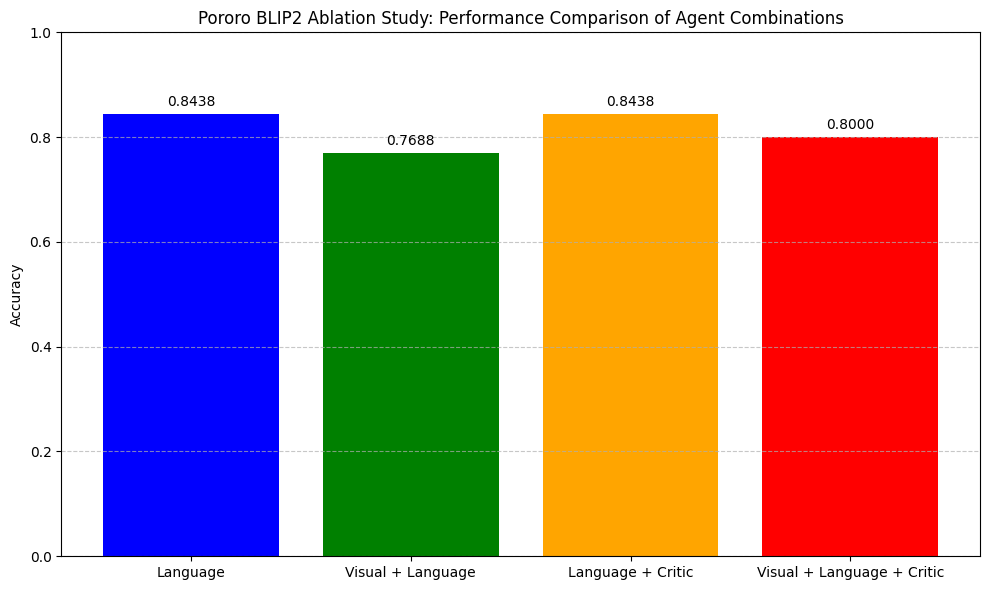

Comparison data saved to: results/analysis/pororo_blip2_comparison_20251111_200626.csv


In [ ]:
# Create visualization of ablation results
# Check if we only have visual configuration (no ablation comparison needed)
print(f"Available configurations: {list(all_results.keys())}")

# Check if only visual configuration exists
visual_only_config = (list(all_results.keys()) == ['visual'])
print(f"visual_only_config: {visual_only_config}")

if visual_only_config:
    print("Visual-only configuration detected. Skipping ablation comparison visualization.")
    print("Visual analysis results have been saved to the analysis directory.")
else:
    print("Multiple configurations or non-visual configuration detected. Proceeding with comparison visualization...")
    # Check if all_accuracies has values from current experiments
    if not all_accuracies:
        print("No accuracy results from current experiments.")
        print("Please run the ablation study experiments first before generating visualization.")

    # Use current experiment results if available
    # Safely access global accuracies variable if it exists
    if 'accuracies' in globals():
        local_accuracies = globals()['accuracies'] if globals()['accuracies'] else []
    else:
        local_accuracies = []

    if not all_accuracies and local_accuracies:
        # Use current experiment results if available
        avg_accuracy = np.mean(local_accuracies) if local_accuracies else 0
        config_name = ''
        if ENABLE_VISUAL_AGENT:
            config_name += 'visual_'
        if ENABLE_LANGUAGE_AGENT:
            config_name += 'language'
        if ENABLE_CRITIC_AGENT:
            config_name += '_critic'
        
        if config_name:
            all_accuracies[config_name] = avg_accuracy
            print(f"Using current experiment accuracy for {config_name}: {avg_accuracy:.4f}")

    # Only proceed with visualization if we have results
    if all_accuracies:
        # Create results dictionary for visualization
        results = {
            "Language": all_accuracies.get('language', 0),
            "Visual + Language": all_accuracies.get('visual_language', 0),
            "Language + Critic": all_accuracies.get('language_critic', 0),
            "Visual + Language + Critic": all_accuracies.get('visual_language_critic', 0)
        }

        # Print values for visualization
        print("\nAccuracy values for visualization:")
        for config, accuracy in results.items():
            print(f"{config}: {accuracy:.4f}")

        # Create folder to save figures if it doesn't exist - save to blip2 folder
        saved_figures_dir = os.path.join(os.getcwd(), "results", "blip2", "saved_figures")
        os.makedirs(saved_figures_dir, exist_ok=True)

        # Generate unique figure name with timestamp
        timestamp = time.strftime("%Y%m%d_%H%M%S")

        # Create visualization
        plt.figure(figsize=(10, 6))
        # Use distinct colors for different configurations
        bars = plt.bar(results.keys(), results.values(), color=['blue', 'green', 'orange', 'red'])
        plt.ylim(0, 1.0)
        plt.ylabel('Accuracy')
        plt.title('Pororo BLIP2 Ablation Study: Performance Comparison of Agent Combinations')

        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{height:.4f}', ha='center', va='bottom')

        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()

        # Save figure with proper naming convention in results/blip2/saved_figures
        figure_path = os.path.join(saved_figures_dir, f"pororo_blip2_comparison_{timestamp}.png")
        plt.savefig(figure_path, dpi=300)
        print(f"Visualization saved to: {figure_path}")

        plt.show()

        # Save comparison results to CSV - save to blip2 comparison folder
        comparison_df = pd.DataFrame([
            {'Configuration': config, 'Accuracy': accuracy}
            for config, accuracy in results.items()
        ])

        comparison_dir = os.path.join(os.getcwd(), "results", "blip2", "comparison")
        os.makedirs(comparison_dir, exist_ok=True)
        comparison_path = os.path.join(comparison_dir, f"pororo_blip2_comparison_{timestamp}.csv")
        comparison_df.to_csv(comparison_path, index=False)
        print(f"Comparison data saved to: {comparison_path}")
    else:
        print("Skipping visualization - no experiment results available.")
